## 1. Problem Definition

### Simple Concept

Problem Definition means clearly deciding **what we want the Deep Learning model to predict**.

For this project, we will build a **binary classification model** to predict whether a customer will **churn or not churn**.

### Problem

A company wants to identify customers who are likely to leave its service.

Our model will use customer information such as:

- Age
- Monthly charges
- Tenure
- Number of services used
- Support calls

### Target

We will predict:

- `0` → Customer will not churn
- `1` → Customer will churn

### Why do we need this?

Before building a model, we need to clearly define:

- What is the input?
- What is the output?
- What type of ML/DL problem is it?

This helps us choose the correct preprocessing, neural network output layer, loss function, and evaluation metrics.

### Decision

We choose **Binary Classification** because there are only two possible outcomes:

**Customer → Churn / Not Churn**

### Project Goal

Build a neural network that learns from historical customer data and predicts whether a new customer is likely to churn.

### Expected Workflow

**Customer Data → Preprocessing → Neural Network → Churn Prediction**

The prediction will be a probability between `0` and `1`, which we will convert into a class:

`Probability ≥ 0.5 → Churn`

`Probability < 0.5 → Not Churn`

## 2. Dataset

### Simple Concept

A dataset is the collection of data that we use to **train and evaluate our Deep Learning model**.

For this project, we will use a **customer churn dataset**.

Each row represents one customer.

Each column represents a customer feature or the target.

### Example Features

| Feature | Meaning |
|---|---|
| `Age` | Customer age |
| `MonthlyCharges` | Monthly service charge |
| `Tenure` | Number of months the customer stayed |
| `SupportCalls` | Number of support calls |
| `ServicesUsed` | Number of services used |
| `Churn` | Target variable |

### Target

`Churn` is our target column.

- `0` → Customer did not churn
- `1` → Customer churned

### Why do we need a dataset?

The neural network needs historical examples to learn the relationship between:

**Customer Features → Churn**

For example:

`Age + Tenure + MonthlyCharges + SupportCalls → Churn`

### Decision

We will use a **small tabular customer churn dataset** so that we can understand the complete Deep Learning workflow without unnecessary dataset complexity.

Later in the notebook, we will:

**Load → Inspect → Analyze → Preprocess → Split → Train → Evaluate**

the dataset.

## 3. Data Inspection

### Simple Concept

Data Inspection means **looking at the dataset before using it for training**.

We check:

- Number of rows and columns
- Feature names
- Data types
- Missing values
- Target values
- Duplicate records

### Why do we need this?

We should not directly give raw data to a neural network.

Data inspection helps us identify problems such as:

- Missing values
- Incorrect data types
- Duplicate rows
- Unexpected target values
- Features that need preprocessing

### Decision

Before preprocessing, we will inspect the dataset and understand its structure.

The basic flow is:

**Load Dataset → Inspect Dataset → Find Problems → Preprocess**

### What this code does

- `head()` → shows sample records
- `shape` → shows rows and columns
- `info()` → shows data types and non-null values
- `isnull().sum()` → finds missing values
- `value_counts()` → checks target distribution
- `duplicated().sum()` → counts duplicate records

### Important Decision

We will **inspect the data before making any preprocessing decision**.

This prevents us from making assumptions about the dataset.

In [3]:
import pandas as pd

data = {
    "Age": [25, 34, 45, 23, 52, 41, 29, 36, 48, 31,
            27, 55, 39, 44, 22, 50, 33, 46, 28, 37],

    "MonthlyCharges": [30, 45, 80, 25, 90, 70, 35, 55, 85, 40,
                       28, 95, 60, 75, 22, 88, 50, 78, 32, 65],

    "Tenure": [2, 12, 36, 1, 48, 30, 5, 18, 42, 8,
               3, 55, 24, 32, 1, 50, 15, 40, 4, 27],

    "SupportCalls": [5, 3, 1, 6, 0, 2, 5, 3, 1, 4,
                     6, 0, 2, 1, 7, 0, 4, 1, 6, 2],

    "ServicesUsed": [1, 2, 4, 1, 5, 3, 1, 3, 5, 2,
                     1, 5, 3, 4, 1, 5, 2, 4, 1, 3],

    "Churn": [1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
              1, 0, 0, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

print(df.head())

#Inspect the Dataset

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["Churn"].value_counts())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

   Age  MonthlyCharges  Tenure  SupportCalls  ServicesUsed  Churn
0   25              30       2             5             1      1
1   34              45      12             3             2      1
2   45              80      36             1             4      0
3   23              25       1             6             1      1
4   52              90      48             0             5      0
Shape: (20, 6)

Data Types:
Age               int64
MonthlyCharges    int64
Tenure            int64
SupportCalls      int64
ServicesUsed      int64
Churn             int64
dtype: object

Missing Values:
Age               0
MonthlyCharges    0
Tenure            0
SupportCalls      0
ServicesUsed      0
Churn             0
dtype: int64

Target Distribution:
Churn
1    10
0    10
Name: count, dtype: int64

Duplicate Rows:
0


## 4. Exploratory Data Analysis (EDA)

### Simple Concept

EDA means **understanding the data using simple statistics and visualizations** before training the model.

We want to understand how the features and target are distributed.

### Why do we need EDA?

EDA helps us identify:

- Feature distributions
- Possible unusual values
- Target class distribution
- Relationships between features and churn

This helps us make better preprocessing and modeling decisions.


### What this tells us

`df.describe()` gives basic statistics such as:

- Mean
- Minimum
- Maximum
- Standard deviation

The churn plot shows how many customers belong to each class.

### Decision

We will check the target distribution before training because an **imbalanced target** can affect model training and evaluation.

We will also use the feature statistics later when deciding whether **feature scaling** is required.

             Age  MonthlyCharges     Tenure  SupportCalls  ServicesUsed  \
count  20.000000       20.000000  20.000000     20.000000     20.000000   
mean   37.250000       57.400000  22.650000      2.950000      2.800000   
std    10.062306       24.305945  18.166699      2.282081      1.542384   
min    22.000000       22.000000   1.000000      0.000000      1.000000   
25%    28.750000       34.250000   4.750000      1.000000      1.000000   
50%    36.500000       57.500000  21.000000      2.500000      3.000000   
75%    45.250000       78.500000  37.000000      5.000000      4.000000   
max    55.000000       95.000000  55.000000      7.000000      5.000000   

           Churn  
count  20.000000  
mean    0.500000  
std     0.512989  
min     0.000000  
25%     0.000000  
50%     0.500000  
75%     1.000000  
max     1.000000  
Churn
1    10
0    10
Name: count, dtype: int64


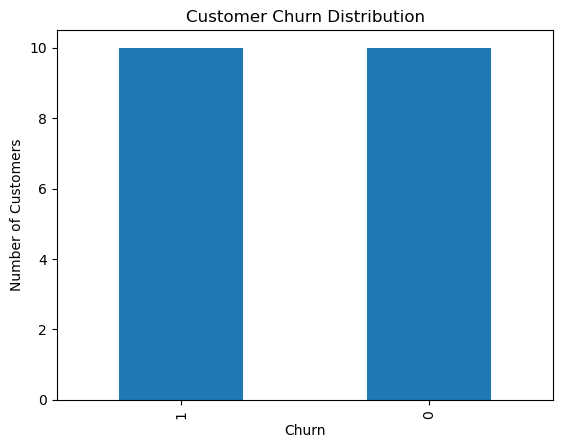

In [4]:
### Python Example

import matplotlib.pyplot as plt

# Basic statistics
print(df.describe())

# Churn distribution
print(df["Churn"].value_counts())

# Plot churn distribution
df["Churn"].value_counts().plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()


## 5. Preprocessing

### Simple Concept

Preprocessing means **preparing the raw data so that it can be given to the neural network**.

Our dataset contains numerical features, but their values are on different scales.

For example:

- `Age` → around 20–55
- `MonthlyCharges` → around 20–100
- `Tenure` → around 1–55
- `SupportCalls` → around 0–7

### Why do we need this?

Neural networks generally train better when numerical features are on a **similar scale**.

Therefore, we will use **StandardScaler**.

Standardization changes the features to approximately:

**Mean = 0**

**Standard Deviation = 1**

### Preprocessing Steps

We will:

1. Separate features and target.
2. Scale the input features.
3. Keep the target unchanged.
`

### What this code does

`X` contains the input features.

`y` contains the target (`Churn`).

`StandardScaler()` creates the scaler.

`fit_transform()` learns the feature statistics and scales the data.

### Important Decision

We use **feature scaling** because the features have different numerical ranges.

We will later make sure the scaler is fitted only on the **training data** to avoid data leakage.

In [5]:

### Python Example

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Create scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])


[[-1.24904122 -1.15658154 -1.1662247   0.92163925 -1.19734219]
 [-0.33137828 -0.52341646 -0.60146698  0.02247901 -0.53215208]
 [ 0.79020975  0.95396871  0.75395156 -0.87668123  0.79822813]
 [-1.45296631 -1.36763656 -1.22270048  1.37121936 -1.19734219]
 [ 1.50394759  1.37607876  1.43166083 -1.32626135  1.46341823]]


## 6. Train / Validation / Test Split

### Simple Concept

We divide the dataset into three parts:

- **Training data** → used to learn patterns
- **Validation data** → used to check and improve the model during development
- **Test data** → used for the final evaluation

### Why do we need this?

If we evaluate the model using the same data used for training, we cannot know whether the model works well on **new unseen data**.

The three sets help us measure generalization.

### Decision

We will use:

- **70% → Training**
- **15% → Validation**
- **15% → Testing**


### Why this approach?

`fit_transform()` is used only on training data.

`transform()` is used on validation and test data.

This prevents information from the validation or test sets from influencing the training process.

### Final Data Flow

**Raw Data**

↓

**Train / Validation / Test Split**

↓

**Fit Scaler on Training Data**

↓

**Transform Train + Validation + Test**

↓

**Ready for Tensor Conversion**

In [6]:

### Python Example

from sklearn.model_selection import train_test_split

# First split: training and temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


### Important: Scaling Without Data Leakage

#Now we scale the data **after splitting**.

#The scaler learns only from the training data.


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


Training: (14, 5)
Validation: (3, 5)
Test: (3, 5)


## 7. Tensor & DataLoader Preparation

### Simple Concept

PyTorch neural networks work with **tensors**.

A `DataLoader` helps us provide the training data to the neural network in **small batches**.

### Why do we need this?

Our data is currently in NumPy/Pandas format.

We need to:

**Data → Tensor → Dataset → DataLoader → Neural Network**

Using batches also makes training more manageable.


### What this code does

- `torch.tensor()` → converts data into PyTorch tensors.
- `TensorDataset()` → combines features and targets.
- `DataLoader()` → provides data in batches.
- `batch_size=4` → sends 4 samples at a time.
- `shuffle=True` → randomly changes training sample order.

### Decision

We use:

**Batch Size = 4**

because our dataset is small and this keeps the example simple.

We shuffle only the **training data** because the model should see training samples in different orders during training.

In [8]:

### Python Example

import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert features to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Convert target to tensors
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


## 8. Baseline Model

### Simple Concept

A baseline model is a **simple starting point** that gives us a reference performance.

Before building a neural network, we first create a simple model.

For binary classification, we can use **Logistic Regression** as our baseline.

### Why do we need this?

We need a reference point to answer:

**"Is our neural network actually improving the prediction?"**

Without a baseline, we cannot easily judge whether the neural network provides useful improvement.

### Decision

We will use **Logistic Regression** as the baseline because:

- It is simple.
- It is suitable for binary classification.
- It trains quickly.
- It gives us a performance reference.

### What this code does

`LogisticRegression()` creates our simple baseline.

`fit()` trains the baseline using training data.

`predict()` generates predictions for validation data.

`accuracy_score()` measures how many predictions are correct.

### Important Decision

We will **save the baseline accuracy** because later we will compare it with our neural network.

**Baseline → Reference**

**Neural Network → Compare against baseline**

In [9]:

### Python Example

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create baseline model
baseline_model = LogisticRegression(random_state=42)

# Train baseline
baseline_model.fit(X_train, y_train)

# Predict validation data
baseline_predictions = baseline_model.predict(X_val)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_val, baseline_predictions)

print("Baseline Validation Accuracy:", baseline_accuracy)


Baseline Validation Accuracy: 1.0


## 9. Neural Network

### Simple Concept

Now we build our **Deep Learning model** using PyTorch.

Our dataset has **5 input features**:

- Age
- MonthlyCharges
- Tenure
- SupportCalls
- ServicesUsed

We will create a small neural network:

**5 Inputs → Hidden Layer → ReLU → Output**

### Why do we need this?

The neural network can learn **non-linear relationships** between customer information and churn.

This allows it to learn more complex patterns than our simple baseline model.

### Decision

We will use:

- Input layer → `5` neurons
- Hidden layer → `8` neurons
- Activation → `ReLU`
- Output layer → `1` neuron

The output neuron represents the probability of churn after applying a sigmoid function during prediction.

### What this code does

`nn.Module` → base class for PyTorch neural networks.

`nn.Linear(5, 8)` → connects 5 input features to 8 hidden neurons.

`nn.ReLU()` → adds non-linearity.

`nn.Linear(8, 1)` → produces one output.

`forward()` → defines how data moves through the network.

### Architecture

**Age**

**MonthlyCharges**

**Tenure**

**SupportCalls**

**ServicesUsed**

↓

**8 Hidden Neurons**

↓

**ReLU**

↓

**1 Output Neuron**

The model currently produces a **raw output (logit)**. We will handle it correctly with the loss function in the next topic.

In [10]:

### Python Example

import torch
import torch.nn as nn

class ChurnModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(5, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

# Create model
model = ChurnModel()

print(model)


ChurnModel(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)


## 10. Loss Function

### Simple Concept

A loss function measures **how far the model's prediction is from the actual answer**.

During training, the neural network tries to **reduce the loss**.

### Why do we need this?

The model needs a way to know whether its predictions are correct or incorrect.

For our problem:

**Prediction → Loss → Backpropagation → Weight Update**

### Decision

Our problem is **binary classification** because the target has two classes:

- `0` → Not Churn
- `1` → Churn

Therefore, we will use:

**`BCEWithLogitsLoss`**

This loss function combines:

- Sigmoid
- Binary Cross Entropy

It is designed to work directly with the model's **raw output (logit)**.


### How it works

Our model produces:

**Raw output (logit)**

↓

**BCEWithLogitsLoss**

↓

**Loss value**

The loss value tells us how well the model is predicting the churn target.

### Important Decision

We **do not add `Sigmoid()` inside the model** because `BCEWithLogitsLoss` already handles the sigmoid calculation internally in a numerically stable way.

Later, when we want to display a prediction probability, we can apply:

```python
probability = torch.sigmoid(output)
```

In [11]:
### Python Example

import torch.nn as nn

# Binary classification loss
loss_function = nn.BCEWithLogitsLoss()

print(loss_function)



BCEWithLogitsLoss()


## 11. Optimizer

### Simple Concept

An optimizer updates the neural network's **weights and biases** so that the loss becomes smaller.

The basic training process is:

**Prediction → Loss → Gradients → Optimizer → Updated Weights**

### Why do we need this?

The neural network starts with randomly initialized parameters.

The optimizer uses the calculated gradients to determine **how the parameters should be changed** to improve the model.

### Decision

We will use the **Adam optimizer**.

Adam is commonly used for neural networks because it automatically adapts the parameter updates using information from previous gradients.

We will start with:

**Learning Rate = 0.001**


### What this code does

`model.parameters()` → gives the trainable weights and biases of the neural network.

`Adam()` → creates the optimizer.

`lr=0.001` → sets the learning rate.

### Decision Summary

| Setting | Choice |
|---|---|
| Optimizer | Adam |
| Learning Rate | 0.001 |

We will later experiment with different hyperparameters and see whether they improve validation performance.

In [12]:
### Python Example

import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(optimizer)


Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 12. Training

### Simple Concept

Training is the process where the neural network **learns from the training data**.

During each training step:

**Input → Prediction → Loss → Gradients → Weight Update**

This process is repeated for multiple **epochs**.

### Why do we need this?

The neural network initially does not know the relationship between customer features and churn.

Training allows it to gradually adjust its weights to make better predictions.

### Decision

We will start with:

- **Epochs = 50**
- **Batch size = 4** (already selected)
- **Optimizer = Adam**
- **Learning rate = 0.001**
- **Loss = BCEWithLogitsLoss**

### What happens here?

`model.train()` → puts the model into training mode.

`model(X_batch)` → performs the forward pass.

`loss_function()` → calculates the loss.

`zero_grad()` → clears old gradients.

`loss.backward()` → calculates new gradients.

`optimizer.step()` → updates the model parameters.

### Important Decision

We train using **only the training DataLoader**.

The validation data will be used separately to check how well the model performs on unseen data during development.

### Expected Output

You should see something similar to:

```text
Epoch [10/50], Loss: 0.55
Epoch [20/50], Loss: 0.42
Epoch [30/50], Loss: 0.32
Epoch [40/50], Loss: 0.25
Epoch [50/50], Loss: 0.20
```

The exact values may be different.

A decreasing training loss generally indicates that the model is learning from the training data.

In [13]:

### Python Example

epochs = 50

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        # Forward pass
        output = model(X_batch)

        # Calculate loss
        loss = loss_function(output, y_batch)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {average_loss:.4f}"
        )


Epoch [10/50], Loss: 0.6979
Epoch [20/50], Loss: 0.6396
Epoch [30/50], Loss: 0.5364
Epoch [40/50], Loss: 0.4836
Epoch [50/50], Loss: 0.4281


## 13. Validation

### Simple Concept

Validation means checking the model's performance on the **validation dataset** after training.

The validation data is **not used to update the model's weights**.

### Why do we need this?

Training loss only tells us how well the model performs on training data.

Validation helps us check whether the model is **generalizing to unseen data**.

It can also help us identify **overfitting**.

### Decision

We will use:

- Training data → learn
- Validation data → monitor and improve
- Test data → final evaluation



### What this code does

`model.eval()` → switches the model to evaluation mode.

`torch.no_grad()` → prevents gradient calculation because we are not training.

`torch.sigmoid()` → converts the raw output into a probability between `0` and `1`.

`>= 0.5` → converts probability into a class.

- `0.5 or higher` → Churn (`1`)
- Less than `0.5` → Not Churn (`0`)

`accuracy_score()` → calculates validation accuracy.

### Important Decision

We use the **validation set during model development**, but we keep the **test set untouched** until final evaluation.

This gives us a more reliable final performance measurement.

In [15]:
### Python Example

from sklearn.metrics import accuracy_score

model.eval()

with torch.no_grad():

    validation_output = model(X_val_tensor)

    # Convert logits to probabilities
    validation_probability = torch.sigmoid(validation_output)

    # Convert probabilities to classes
    validation_predictions = (
        validation_probability >= 0.5
    ).float()

validation_accuracy = accuracy_score(
    y_val,
    validation_predictions.numpy().ravel()
)

print("Validation Accuracy:", validation_accuracy)


Validation Accuracy: 1.0


## 14. Hyperparameter Experiments

### Simple Concept

Hyperparameters are settings that we choose **before training the model**.

Examples:

- Learning rate
- Number of hidden neurons
- Number of epochs
- Batch size

We can try different values and compare their validation performance.

### Why do we need this?

One set of hyperparameters may not give the best model.

Experiments help us understand whether changing the model settings improves **validation performance**.

### Decision

We will experiment with the **hidden layer size**.

We will compare:

- 4 neurons
- 8 neurons
- 16 neurons

We will keep the other settings unchanged so that we can understand the effect of this one change.

### What we are comparing

| Hyperparameter | Values |
|---|---|
| Hidden neurons | 4, 8, 16 |
| Learning rate | 0.001 |
| Epochs | 50 |
| Optimizer | Adam |

### Important Decision

We change **one important hyperparameter** while keeping the others fixed.

This makes the experiment easier to understand.

We will use the validation results later when deciding which model configuration to continue with.

In [16]:

### Python Example

hidden_sizes = [4, 8, 16]

for hidden_size in hidden_sizes:

    print(f"\nTesting hidden size: {hidden_size}")

    # Create a new model
    experiment_model = nn.Sequential(
        nn.Linear(5, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1)
    )

    # Loss function
    experiment_loss = nn.BCEWithLogitsLoss()

    # Optimizer
    experiment_optimizer = optim.Adam(
        experiment_model.parameters(),
        lr=0.001
    )

    # Train
    for epoch in range(50):

        experiment_model.train()

        for X_batch, y_batch in train_loader:

            output = experiment_model(X_batch)

            loss = experiment_loss(output, y_batch)

            experiment_optimizer.zero_grad()

            loss.backward()

            experiment_optimizer.step()

    # Validation
    experiment_model.eval()

    with torch.no_grad():
        output = experiment_model(X_val_tensor)
        probability = torch.sigmoid(output)
        predictions = (probability >= 0.5).float()

    accuracy = accuracy_score(
        y_val,
        predictions.numpy().ravel()
    )

    print("Validation Accuracy:", accuracy)



Testing hidden size: 4
Validation Accuracy: 1.0

Testing hidden size: 8
Validation Accuracy: 0.6666666666666666

Testing hidden size: 16
Validation Accuracy: 1.0


## 15. Error Analysis

### Simple Concept

Error Analysis means **examining the predictions that the model got wrong**.

Instead of looking only at accuracy, we check:

- Which customers were predicted incorrectly?
- Were actual churners predicted as non-churners?
- Were non-churners predicted as churners?

### Why do we need this?

Accuracy tells us **how many predictions were correct**, but it does not tell us **what type of mistakes the model made**.

Error analysis helps us understand where the model is struggling.


### Understanding the Confusion Matrix

For binary classification:

```text
                 Predicted
                0       1

Actual  0      TN      FP
        1      FN      TP
```

- **TN** → Correctly predicted not churn
- **FP** → Predicted churn, but customer did not churn
- **FN** → Predicted not churn, but customer actually churned
- **TP** → Correctly predicted churn

### Why is this important?

For a customer churn problem, **False Negatives** can be important because the company may fail to identify a customer who is actually going to leave.

Therefore, we should not rely only on accuracy.

We will use the error analysis to understand what the model needs to improve.

In [17]:

### Python Example

from sklearn.metrics import confusion_matrix

# Get validation predictions
model.eval()

with torch.no_grad():
    output = model(X_val_tensor)
    probability = torch.sigmoid(output)
    predictions = (probability >= 0.5).float()

# Confusion matrix
cm = confusion_matrix(
    y_val,
    predictions.numpy().ravel()
)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[1 0]
 [0 2]]


## 16. Model Improvement

### Simple Concept

Model Improvement means **making changes to the model or training process to improve validation performance**.

After training and error analysis, we identify areas where the model can be improved.

### Why do we need this?

Our first neural network is only a **baseline Deep Learning model**.

The first model may:

- Underfit the data
- Overfit the training data
- Make many incorrect predictions

We can improve it by changing suitable settings.

### Decision

Based on our hyperparameter experiment, we will select a suitable hidden-layer size and build an improved model.

We will also add a **second hidden layer** so the network can learn more complex patterns.

Architecture:

**5 Inputs → 16 Neurons → ReLU → 8 Neurons → ReLU → 1 Output**

### What changed?

**Original model:**

```text
5 → 8 → 1
```

**Improved model:**

```text
5 → 16 → 8 → 1
```

The improved model has more hidden layers and neurons, giving it greater capacity to learn patterns.

### Important Decision

We should **not assume that a larger network is automatically better**.

We will compare the improved model's validation performance with the original model and baseline.

The validation results will determine whether this change is useful.

In [18]:

### Python Example

improved_model = nn.Sequential(
    nn.Linear(5, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

improved_loss = nn.BCEWithLogitsLoss()

improved_optimizer = optim.Adam(
    improved_model.parameters(),
    lr=0.001
)

print(improved_model)


Sequential(
  (0): Linear(in_features=5, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
)


# 17. Final Evaluation

### Simple Concept

Final Evaluation means testing the selected model on the **test dataset**, which has not been used for training or model selection.

### Why do we need this?

The test set gives us the final estimate of how the model performs on **completely unseen data**.

### Decision

We use the test set **only at the end**.



### What this code does

- `model.eval()` → puts the model into evaluation mode.
- `torch.no_grad()` → disables gradient calculation.
- `sigmoid()` → converts logits into probabilities.
- `0.5` → converts probability into a class.
- `accuracy_score()` → calculates final accuracy.
- `classification_report()` → shows precision, recall and F1-score.

---

# 18. Model Selection

### Simple Concept

Model Selection means choosing the model configuration that we will use as the **final model**.

We have multiple candidates:

- Baseline Logistic Regression
- Original Neural Network
- Improved Neural Network
- Different hyperparameter configurations

### Why do we need this?

We should not select a model only because it has the highest training accuracy.

We should consider:

- Validation performance
- Test performance
- Model complexity
- Generalization
- Training behavior

### Decision

The **validation results** are used for model selection.

The test set is kept separate until final evaluation.

### Example Comparison

```python
print("Baseline Validation Accuracy:",
      baseline_accuracy)

print("Original Neural Network Validation Accuracy:",
      validation_accuracy)

print("Improved Neural Network Test Accuracy:",
      test_accuracy)
```

### Important Point

We should choose the model based on the evidence from our experiments rather than automatically assuming that the most complex model is the best model.

---

# 19. Save Model

### Simple Concept

After selecting the final model, we save its learned parameters so that we can use the model later without training it again.

### Why do we need this?

Training can take time.

Saving the model allows us to:

- Reuse the trained model
- Deploy it later
- Make predictions on new data

### Python Example

```python
torch.save(
    improved_model.state_dict(),
    "customer_churn_model.pth"
)

print("Model saved successfully.")
```

### Load the Model

```python
loaded_model = nn.Sequential(
    nn.Linear(5, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

loaded_model.load_state_dict(
    torch.load(
        "customer_churn_model.pth",
        weights_only=True
    )
)

loaded_model.eval()

print("Model loaded successfully.")
```

### Important Decision

We save the **model parameters (`state_dict`)** rather than saving the entire model object.

This is the common PyTorch approach for storing learned weights.

---

# 20. Inference

### Simple Concept

Inference means using the **trained model to make predictions on new, unseen data**.

For example, we receive information about a new customer and want to predict whether they may churn.

### Why do we need this?

Training creates the model.

Inference is how we actually **use the trained model**.

   

In [31]:
## Simple Inference

# New customer
new_customer = [[35, 60, 18, 4, 2]]

# Scale the data
new_customer = scaler.transform(new_customer)

# Convert to tensor
new_customer = torch.tensor(
    new_customer,
    dtype=torch.float32
)

# Prediction
improved_model.eval()

with torch.no_grad():
    output = improved_model(new_customer)
    probability = torch.sigmoid(output).item()

prediction = 1 if probability >= 0.5 else 0

print("Churn Probability:", probability)
print("Prediction:", prediction)
```

### If you get the scaler warning

You can **ignore it for this simple learning example**. It is only a warning, not an error.

### If you get `improved_model is not defined`

Run the cell where you created the improved model first.

SyntaxError: invalid syntax (3929329535.py, line 3)

In [19]:
### Python Example

from sklearn.metrics import accuracy_score, classification_report

improved_model.eval()

with torch.no_grad():
    test_output = improved_model(X_test_tensor)
    test_probability = torch.sigmoid(test_output)
    test_predictions = (test_probability >= 0.5).float()

test_accuracy = accuracy_score(
    y_test,
    test_predictions.numpy().ravel()
)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_predictions.numpy().ravel()
    )
)


Test Accuracy: 0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\Users\nanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
